In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [2]:
df = pd.read_csv(r"D:\ML Project\Stroke project\archive (1)\healthcare-dataset-stroke-data.csv")

print(df.head())

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


In [3]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
wo

In [4]:
df["bmi"].fillna(df["bmi"].mean(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_12464\2646885692.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["bmi"].fillna(df["bmi"].mean(), inplace=True)


In [5]:
df.drop("id", axis=1, inplace=True)

In [6]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = encoder.fit_transform(df[col])

In [7]:
print(df.describe())

            gender          age  hypertension  heart_disease  ever_married  \
count  5110.000000  5110.000000   5110.000000    5110.000000   5110.000000   
mean      0.414286    43.226614      0.097456       0.054012      0.656164   
std       0.493044    22.612647      0.296607       0.226063      0.475034   
min       0.000000     0.080000      0.000000       0.000000      0.000000   
25%       0.000000    25.000000      0.000000       0.000000      0.000000   
50%       0.000000    45.000000      0.000000       0.000000      1.000000   
75%       1.000000    61.000000      0.000000       0.000000      1.000000   
max       2.000000    82.000000      1.000000       1.000000      1.000000   

         work_type  Residence_type  avg_glucose_level          bmi  \
count  5110.000000     5110.000000        5110.000000  5110.000000   
mean      2.167710        0.508023         106.147677    28.893237   
std       1.090293        0.499985          45.283560     7.698018   
min       0.00000

In [8]:
print(df.mean(numeric_only=True))

gender                 0.414286
age                   43.226614
hypertension           0.097456
heart_disease          0.054012
ever_married           0.656164
work_type              2.167710
Residence_type         0.508023
avg_glucose_level    106.147677
bmi                   28.893237
smoking_status         1.376908
stroke                 0.048728
dtype: float64


In [9]:
print(df.median(numeric_only=True))

gender                0.000
age                  45.000
hypertension          0.000
heart_disease         0.000
ever_married          1.000
work_type             2.000
Residence_type        1.000
avg_glucose_level    91.885
bmi                  28.400
smoking_status        2.000
stroke                0.000
dtype: float64


In [10]:
print(df.corr())

                     gender       age  hypertension  heart_disease  \
gender             1.000000 -0.028202      0.020994       0.085447   
age               -0.028202  1.000000      0.276398       0.263796   
hypertension       0.020994  0.276398      1.000000       0.108306   
heart_disease      0.085447  0.263796      0.108306       1.000000   
ever_married      -0.031005  0.679125      0.164243       0.114644   
work_type          0.056422 -0.361642     -0.051761      -0.028023   
Residence_type    -0.006738  0.014180     -0.007913       0.003092   
avg_glucose_level  0.055180  0.238171      0.174474       0.161857   
bmi               -0.026109  0.325942      0.160189       0.038899   
smoking_status    -0.062581  0.265199      0.111038       0.048460   
stroke             0.008929  0.245257      0.127904       0.134914   

                   ever_married  work_type  Residence_type  avg_glucose_level  \
gender                -0.031005   0.056422       -0.006738           0.055180 

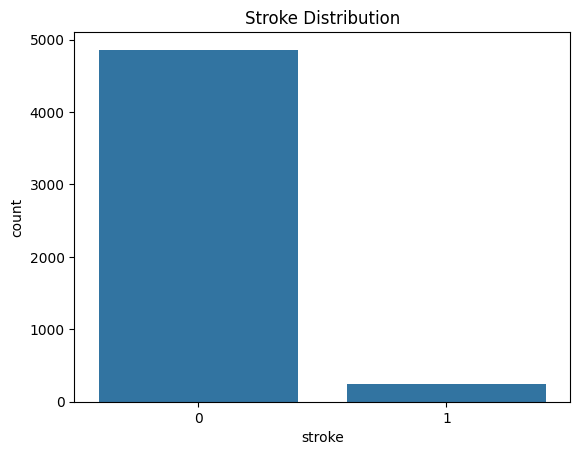

In [11]:
sns.countplot(x="stroke", data=df)
plt.title("Stroke Distribution")
plt.show()

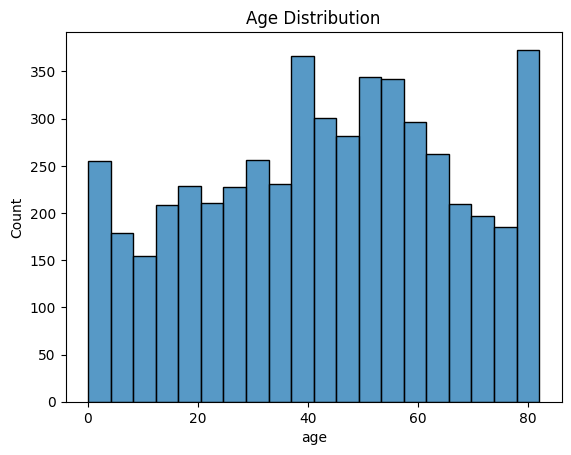

In [12]:
sns.histplot(df["age"], bins=20)
plt.title("Age Distribution")
plt.show()

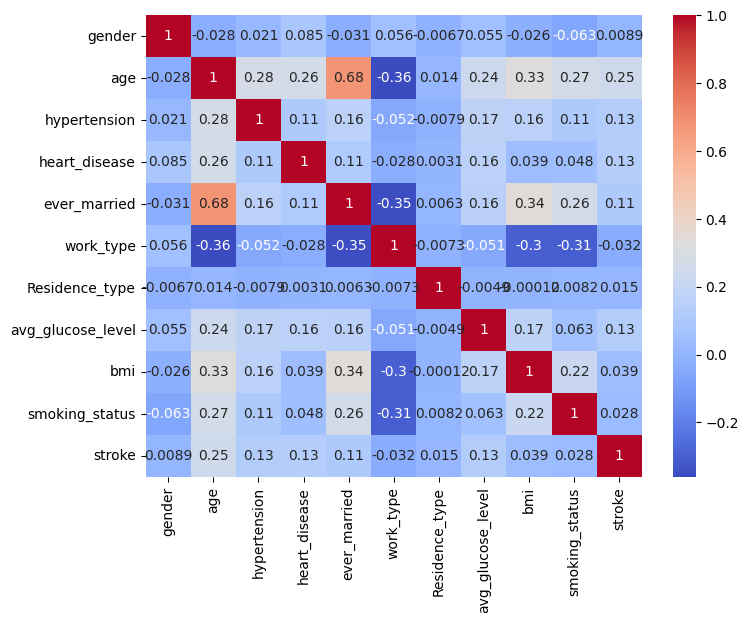

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [14]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

In [15]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred1 = lr.predict(X_test)

print("Logistic Regression Accuracy")
print(accuracy_score(y_test, pred1))

Logistic Regression Accuracy
0.9393346379647749


In [18]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred2 = rf.predict(X_test)

print("Random Forest Accuracy")
print(accuracy_score(y_test, pred2))

Random Forest Accuracy
0.9383561643835616


In [19]:
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



In [20]:
joblib.dump(rf, "stroke_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully
